<a href="https://colab.research.google.com/github/Hemant-1Kumar/Hemant-1Kumar/blob/main/Bharat_intern_task_1_stock_price_prediction_using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK**-1 ***STOCK*** ***PRICE*** ***PREDICTION***

* Take stock price of any company you want and predicts its price by using LSTM. Use only Jupyter notebook code








         Date      High       Low      Open     Close     Volume  Adj Close
0  23-05-2002  1.242857  1.145714  1.156429  1.196429  104790000   1.196429
1  24-05-2002  1.225000  1.197143  1.214286  1.210000   11104800   1.210000
2  28-05-2002  1.232143  1.157143  1.213571  1.157143    6609400   1.157143
3  29-05-2002  1.164286  1.085714  1.164286  1.103571    6757800   1.103571
4  30-05-2002  1.107857  1.071429  1.107857  1.071429   10154200   1.071429
10 epoch loss 0.005332742
20 epoch loss 0.004534568
30 epoch loss 0.004178118
40 epoch loss 0.0036132506
50 epoch loss 0.0024743874
60 epoch loss 8.059629e-05
70 epoch loss 3.2186137e-05
80 epoch loss 8.0052174e-05
90 epoch loss 5.4829925e-05


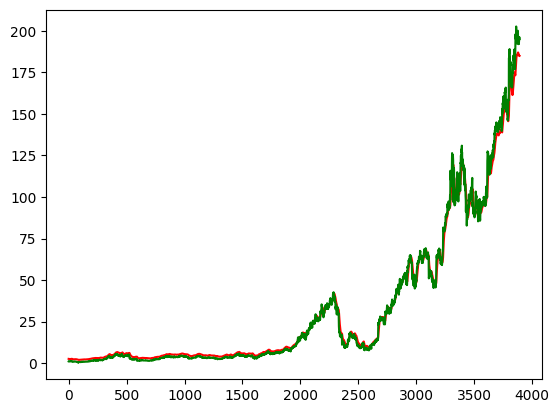

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

df= pd.read_csv("netflix.csv")
print(df.head())
closed_prices = df["Close"]
seq_len = 15


mm = MinMaxScaler()
scaled_price = mm.fit_transform(np.array(closed_prices)[... , None]).squeeze()

X=[]
Y=[]

for i in range(len(scaled_price) - seq_len):
    X.append(scaled_price[i : i+ seq_len])
    Y.append(scaled_price[i+seq_len])

X = np.array(X)[... , None]
Y = np.array(Y)[... ,None]

train_x = torch.from_numpy(X[:int(0.8*X.shape[0])]).float()
train_y = torch.from_numpy(Y[:int(0.8*Y.shape[0])]).float()
test_x = torch.from_numpy(X[:int(0.8*X.shape[0])]).float()
test_y = torch.from_numpy(Y[:int(0.8*Y.shape[0])]).float()

class Model(nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size , hidden_size,batch_first=True)
        self.fc=nn.Linear(hidden_size, 1)
    def forward(self , x):
        output,(hidden,cell)=self.lstm(x)
        return self.fc(hidden[-1,:])

model = Model(1,64)

optimizer=torch.optim.Adam(model.parameters(), lr=0.001)

loss_fn = nn.MSELoss()
num_epochs=100

for epoch in range(num_epochs):
    output = model(train_x)
    loss=loss_fn(output,train_y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10==0 and epoch !=0:
        print(epoch , "epoch loss", loss.detach().numpy())

model.eval()
with torch.no_grad():
    output=model(test_x)
pred=mm.inverse_transform(output.numpy())
real=mm.inverse_transform(test_y.numpy())

plt.plot(pred.squeeze(),color="red",label="predicted")
plt.plot(real.squeeze(),color="green",label="real")
plt.show()
